# gd endpoints stay near minimal sharpness up to the stability boundary

This notebook follows the previous post on the same non-convex loss

$$
L(x,y)=\frac12(1-xy)^2.
$$

The previous post explained the thresholds `eta = 1/2` and `eta = 1`.
This one asks a different question:

> among the stable minima, does GD end near minimal sharpness or near the edge?

For a scalar quadratic,

$$
q(z)=\frac12 \lambda z^2,
\qquad
z_{k+1}=(1-\eta\lambda)z_k.
$$

The edge is `eta * lambda = 2`.
For our loss, at a minimizer `xy=1`, the non-zero Hessian eigenvalue is

$$
s(x,y)=x^2+y^2.
$$

So:

- minimal sharpness is `s = 2`, reached at `x=y=1` and `x=y=-1`,
- the edge is `eta * s(x,y) = 2`.

The notebook uses deterministic grids of initializations. It measures endpoint sharpness and whether late `eta * s(x,y)` stays near `2`.


In [1]:

from pathlib import Path
import json

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

MINIMIZER_MONOTONE = 0
MINIMIZER_OSCILLATORY = 1
SADDLE = 2
BLOW_UP = 3
UNRESOLVED = 4
CONVERGED = (MINIMIZER_MONOTONE, MINIMIZER_OSCILLATORY)

ROOT = Path.cwd()
if not (ROOT / '_posts').exists() and (ROOT.parent / '_posts').exists():
    ROOT = ROOT.parent
IMG_DIR = ROOT / 'assets' / 'images' / 'post-5'
DATA_DIR = ROOT / 'assets' / 'data'
IMG_DIR.mkdir(parents=True, exist_ok=True)
DATA_DIR.mkdir(parents=True, exist_ok=True)


def grid_starts(n=141, radius=3.0, shape='disk', annulus_inner=2.0):
    grid = np.linspace(-radius, radius, n)
    X, Y = np.meshgrid(grid, grid)
    if shape == 'disk':
        mask = X * X + Y * Y <= radius * radius + 1e-12
    elif shape == 'square':
        mask = np.ones_like(X, dtype=bool)
    elif shape == 'diamond':
        mask = np.abs(X) + np.abs(Y) <= radius + 1e-12
    elif shape == 'annulus':
        R2 = X * X + Y * Y
        mask = (R2 <= radius * radius + 1e-12) & (R2 >= annulus_inner * annulus_inner - 1e-12)
    else:
        raise ValueError(f'unknown shape: {shape}')
    return X, Y, mask


def stable_imbalance_radius(eta):
    return np.sqrt(max((2.0 / float(eta)) ** 2 - 4.0, 0.0))


def final_sharpness(imbalance):
    return np.sqrt(np.asarray(imbalance) ** 2 + 4.0)


def sharpness(imbalance, residual):
    return np.sqrt(np.asarray(imbalance) ** 2 + 4.0 * (np.asarray(residual) + 1.0) ** 2)


def run_gd_batch(x0, y0, eta, steps=420, keep_history=False):
    x = np.asarray(x0, dtype=float).ravel().copy()
    y = np.asarray(y0, dtype=float).ravel().copy()
    n = x.size

    labels = np.full(n, UNRESOLVED, dtype=np.int8)
    residual = x * y - 1.0
    imbalance = x * x - y * y
    previous_residual = residual.copy()
    sign_flips = np.zeros(n, dtype=np.int16)
    residual_hits = (np.abs(residual) < 1e-7).astype(np.int16)
    origin_hits = ((np.abs(x) < 1e-6) & (np.abs(y) < 1e-6) & (np.abs(residual + 1.0) < 1e-6)).astype(np.int16)

    if keep_history:
        imbalance_hist = np.empty((steps + 1, n), dtype=np.float64)
        residual_hist = np.empty((steps + 1, n), dtype=np.float64)
        imbalance_hist[0] = imbalance
        residual_hist[0] = residual
    else:
        imbalance_hist = residual_hist = None

    labels[(origin_hits >= 5)] = SADDLE
    labels[(labels == UNRESOLVED) & (residual_hits >= 5)] = MINIMIZER_MONOTONE

    for k in range(1, steps + 1):
        active = labels == UNRESOLVED
        if np.any(active):
            xa = x[active]
            ya = y[active]
            ra = xa * ya - 1.0
            xa_next = xa - eta * ra * ya
            ya_next = ya - eta * ra * xa

            x[active] = xa_next
            y[active] = ya_next
            residual_new = xa_next * ya_next - 1.0
            imbalance_new = xa_next * xa_next - ya_next * ya_next
            sign_flips[active] += previous_residual[active] * residual_new < 0.0
            previous_residual[active] = residual_new
            residual[active] = residual_new
            imbalance[active] = imbalance_new

            bad = active.copy()
            bad[active] = (~np.isfinite(xa_next)) | (~np.isfinite(ya_next)) | (np.abs(xa_next) > 1e8) | (np.abs(ya_next) > 1e8)
            labels[bad] = BLOW_UP

            active = labels == UNRESOLVED
            residual_hits[active] = np.where(np.abs(residual[active]) < 1e-7, residual_hits[active] + 1, 0)
            origin = (np.abs(x[active]) < 1e-6) & (np.abs(y[active]) < 1e-6) & (np.abs(residual[active] + 1.0) < 1e-6)
            origin_hits[active] = np.where(origin, origin_hits[active] + 1, 0)
            labels[(labels == UNRESOLVED) & (origin_hits >= 5)] = SADDLE
            done = (labels == UNRESOLVED) & (residual_hits >= 5)
            labels[done] = np.where(sign_flips[done] == 0, MINIMIZER_MONOTONE, MINIMIZER_OSCILLATORY)

        if keep_history:
            imbalance_hist[k] = imbalance
            residual_hist[k] = residual

    return labels, imbalance, residual, imbalance_hist, residual_hist


def tail_edge_stats(labels, imbalance_hist, residual_hist, eta, edge_tol=0.10):
    conv = np.isin(labels, CONVERGED)
    if not np.any(conv):
        return np.nan, 0.0

    residuals = residual_hist[:, conv]
    imbalances = imbalance_hist[:, conv]
    initial = np.maximum(np.abs(residuals[0]), 1e-12)
    hits = np.abs(residuals) <= 0.01 * initial[None, :]
    has_hit = np.any(hits, axis=0)
    starts = np.argmax(hits, axis=0)
    eta_s = eta * sharpness(imbalances, residuals)

    medians = []
    near_edge = []
    for j, ok in enumerate(has_hit):
        if not ok:
            near_edge.append(False)
            continue
        tail = eta_s[starts[j]:, j]
        medians.append(float(np.median(tail)))
        near_edge.append(float(np.median(np.abs(tail - 2.0))) <= edge_tol)
    return float(np.median(medians)), float(np.mean(near_edge))


def summarize_eta_grid(etas, n=141, shape='disk', radius=3.0, steps=420):
    X, Y, mask = grid_starts(n=n, radius=radius, shape=shape)
    rows = []
    for eta in etas:
        labels, _, _, imbalance_hist, residual_hist = run_gd_batch(X[mask], Y[mask], eta, steps=steps, keep_history=True)
        conv = np.isin(labels, CONVERGED)
        final_abs_imbalance = np.abs(imbalance_hist[-1, conv])
        s_final = final_sharpness(final_abs_imbalance)
        radius_edge = stable_imbalance_radius(eta)
        median_tail, near_edge = tail_edge_stats(labels, imbalance_hist, residual_hist, eta)
        rows.append({
            'eta': float(eta),
            'count': int(np.sum(conv)),
            'median_s_final': float(np.median(s_final)),
            'p90_s_final': float(np.percentile(s_final, 90)),
            'max_s_final': float(np.max(s_final)),
            'edge_sharpness': float(2.0 / eta),
            'edge_imbalance_radius': float(radius_edge),
            'near_min_fraction': float(np.mean(final_abs_imbalance <= 0.25 * radius_edge)),
            'middle_fraction': float(np.mean((final_abs_imbalance > 0.25 * radius_edge) & (final_abs_imbalance < 0.75 * radius_edge))),
            'edge_fraction': float(np.mean(final_abs_imbalance >= 0.75 * radius_edge)),
            'median_position_in_window': float(np.median(final_abs_imbalance / max(radius_edge, 1e-12))),
            'median_tail_eta_sharpness': median_tail,
            'near_edge_fraction': near_edge,
        })
    return rows


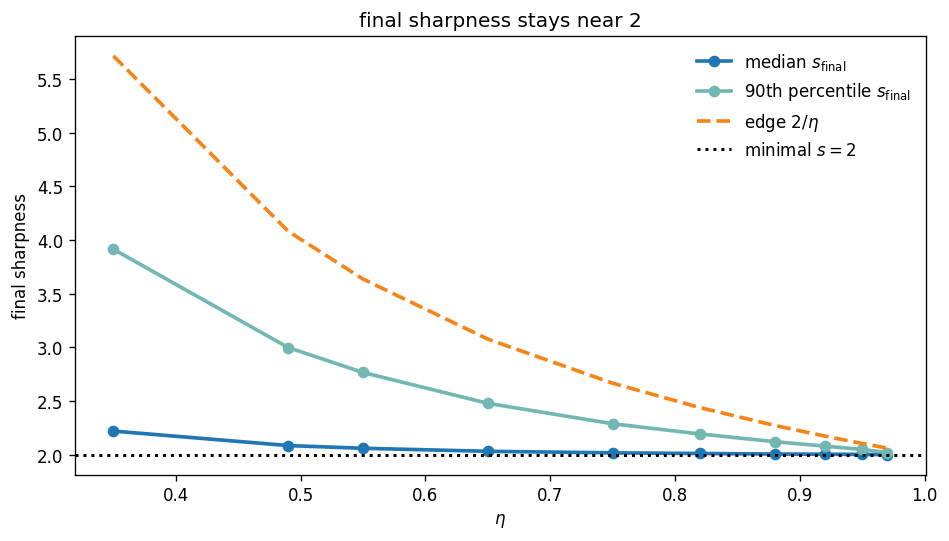

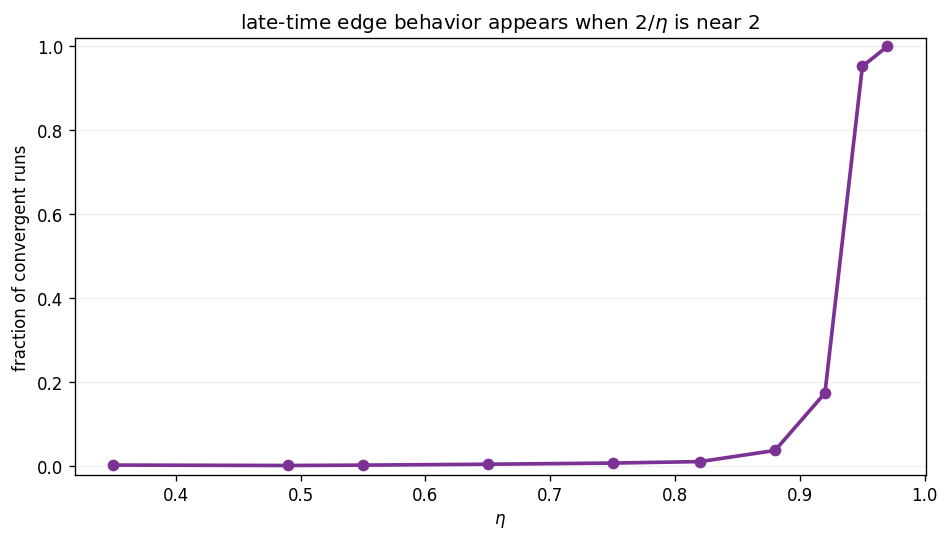

eta=0.35 | convergent=15262 | median s_final=2.221 | median position=0.180 | near-min frac=0.594 | edge frac=0.048 | p90 s_final=3.914 | edge=2/eta=5.714 | median tail eta*sharpness=0.777 | near edge frac=0.003
eta=0.49 | convergent=13066 | median s_final=2.086 | median position=0.167 | near-min frac=0.610 | edge frac=0.046 | p90 s_final=2.999 | edge=2/eta=4.082 | median tail eta*sharpness=1.022 | near edge frac=0.002
eta=0.55 | convergent=11822 | median s_final=2.061 | median position=0.164 | near-min frac=0.609 | edge frac=0.048 | p90 s_final=2.767 | edge=2/eta=3.636 | median tail eta*sharpness=1.133 | near edge frac=0.003
eta=0.65 | convergent=9882 | median s_final=2.033 | median position=0.155 | near-min frac=0.612 | edge frac=0.044 | p90 s_final=2.479 | edge=2/eta=3.077 | median tail eta*sharpness=1.321 | near edge frac=0.005
eta=0.75 | convergent=8388 | median s_final=2.018 | median position=0.154 | near-min frac=0.609 | edge frac=0.042 | p90 s_final=2.289 | edge=2/eta=2.667 | me

In [2]:

ETAS = [0.35, 0.49, 0.55, 0.65, 0.75, 0.82, 0.88, 0.92, 0.95, 0.97]
summary = summarize_eta_grid(ETAS, n=141, shape='disk')


def plot_final_sharpness(rows, save_path):
    eta = np.array([row['eta'] for row in rows])
    fig, ax = plt.subplots(figsize=(7.8, 4.4), constrained_layout=True)
    ax.plot(eta, [row['median_s_final'] for row in rows], marker='o', lw=2.2, color='#1f77b4', label=r'median $s_{\mathrm{final}}$')
    ax.plot(eta, [row['p90_s_final'] for row in rows], marker='o', lw=2.2, color='#72b7b2', label=r'90th percentile $s_{\mathrm{final}}$')
    ax.plot(eta, [row['edge_sharpness'] for row in rows], lw=2.2, ls='--', color='#f58518', label=r'edge $2/\eta$')
    ax.axhline(2.0, lw=1.8, ls=':', color='black', label=r'minimal $s=2$')
    ax.set_xlabel(r'$\eta$')
    ax.set_ylabel('final sharpness')
    ax.set_title('final sharpness stays near 2')
    ax.legend(frameon=False, loc='upper right')
    fig.savefig(save_path, dpi=220, bbox_inches='tight')
    plt.show()


def plot_late_edge(rows, save_path):
    eta = np.array([row['eta'] for row in rows])
    fig, ax = plt.subplots(figsize=(7.8, 4.4), constrained_layout=True)
    ax.plot(eta, [row['near_edge_fraction'] for row in rows], marker='o', lw=2.2, color='#7b3294')
    ax.set_xlabel(r'$\eta$')
    ax.set_ylabel('fraction of convergent runs')
    ax.set_ylim(-0.02, 1.02)
    ax.set_title(r'late-time edge behavior appears when $2/\eta$ is near 2')
    ax.grid(axis='y', alpha=0.18)
    fig.savefig(save_path, dpi=220, bbox_inches='tight')
    plt.show()


plot_final_sharpness(summary, IMG_DIR / 'final_sharpness.png')
plot_late_edge(summary, IMG_DIR / 'late_edge_behavior.png')

for row in summary:
    print(
        f"eta={row['eta']:.2f} | convergent={row['count']:4d} | "
        f"median s_final={row['median_s_final']:.3f} | "
        f"median position={row['median_position_in_window']:.3f} | "
        f"near-min frac={row['near_min_fraction']:.3f} | "
        f"edge frac={row['edge_fraction']:.3f} | "
        f"p90 s_final={row['p90_s_final']:.3f} | "
        f"edge=2/eta={row['edge_sharpness']:.3f} | "
        f"median tail eta*sharpness={row['median_tail_eta_sharpness']:.3f} | "
        f"near edge frac={row['near_edge_fraction']:.3f}"
    )


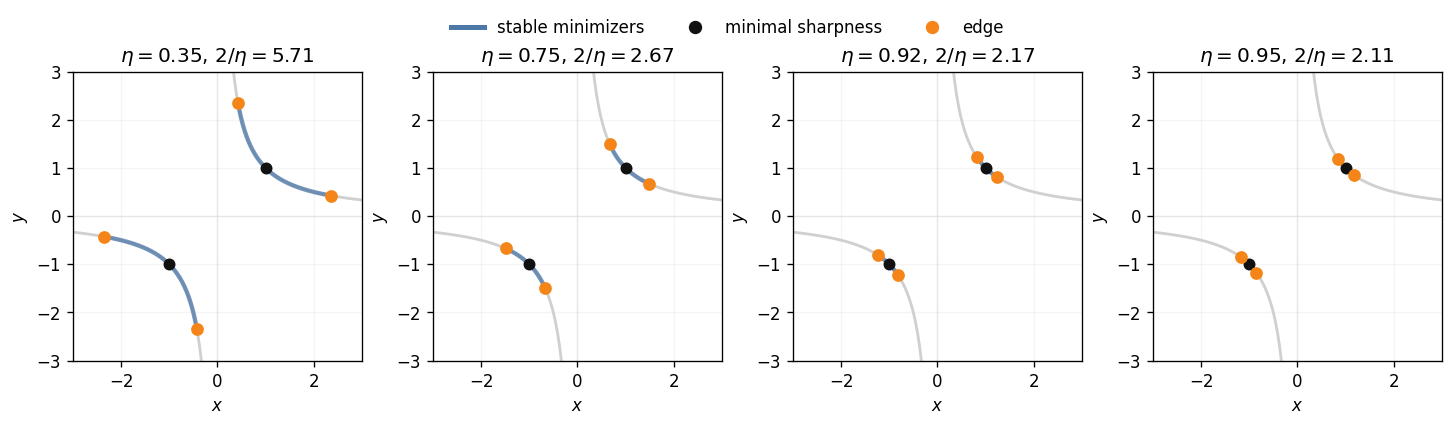

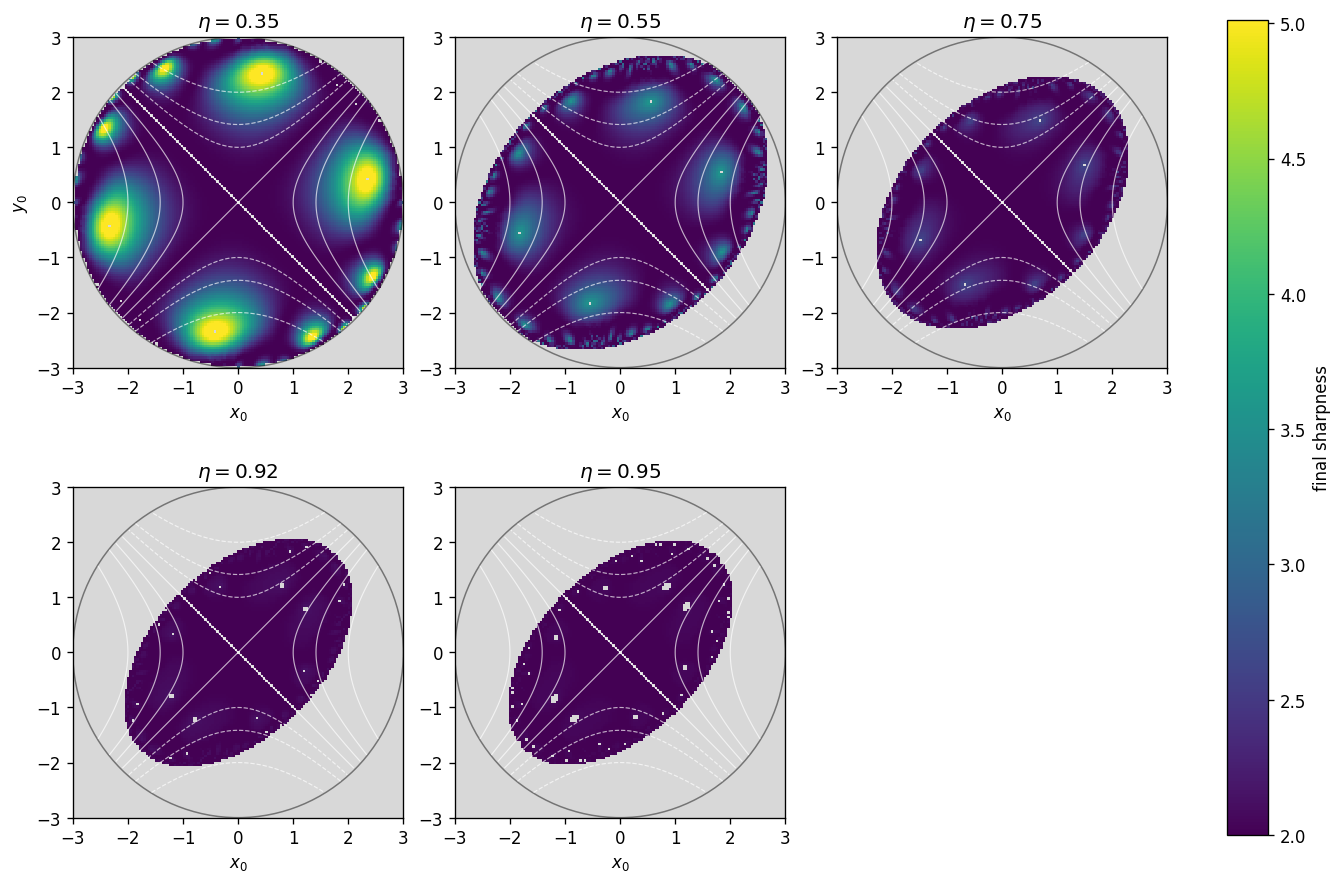

In [3]:

def minimizer_branches(x_min=1 / 3, x_max=3.0, n=500):
    x_pos = np.linspace(x_min, x_max, n)
    x_neg = np.linspace(-x_max, -x_min, n)
    return x_pos, 1 / x_pos, x_neg, 1 / x_neg


def stable_arc(eta, n=500):
    radius_edge = stable_imbalance_radius(eta)
    imbalance = np.linspace(-radius_edge, radius_edge, n)
    s = final_sharpness(imbalance)
    x = np.sqrt((s + imbalance) / 2.0)
    y = np.sqrt((s - imbalance) / 2.0)
    return x, y


def edge_points(eta):
    points = []
    for imbalance in [-stable_imbalance_radius(eta), stable_imbalance_radius(eta)]:
        s = final_sharpness(imbalance)
        x = np.sqrt((s + imbalance) / 2.0)
        y = np.sqrt((s - imbalance) / 2.0)
        points.extend([(x, y), (-x, -y)])
    return np.array(points)


def style_xy(ax):
    ax.axhline(0, color='#eeeeee', lw=0.8, zorder=0)
    ax.axvline(0, color='#eeeeee', lw=0.8, zorder=0)
    ax.set_xlim(-3, 3)
    ax.set_ylim(-3, 3)
    ax.set_aspect('equal', adjustable='box')
    ax.set_xlabel('$x$')
    ax.set_ylabel('$y$')
    ax.grid(alpha=0.12)


def plot_stable_minimizers_with_edge(etas, save_path):
    fig, axes = plt.subplots(1, len(etas), figsize=(3.0 * len(etas), 3.15), constrained_layout=True)
    x_pos, y_pos, x_neg, y_neg = minimizer_branches()
    for ax, eta in zip(np.atleast_1d(axes), etas):
        x, y = stable_arc(eta)
        edge = edge_points(eta)
        ax.plot(x_pos, y_pos, color='#d0d0d0', lw=1.7)
        ax.plot(x_neg, y_neg, color='#d0d0d0', lw=1.7)
        ax.plot(x, y, color='#4c78a8', lw=2.6, alpha=0.75)
        ax.plot(-x, -y, color='#4c78a8', lw=2.6, alpha=0.75)
        ax.scatter([1, -1], [1, -1], s=38, color='#111111', zorder=5)
        ax.scatter(edge[:, 0], edge[:, 1], s=44, color='#f58518', zorder=6)
        ax.set_title(rf'$\eta={eta:.2f}$, $2/\eta={2 / eta:.2f}$')
        style_xy(ax)

    handles = [
        Line2D([0], [0], color='#4c78a8', lw=3, label='stable minimizers'),
        Line2D([0], [0], marker='o', color='none', markerfacecolor='#111111', markeredgecolor='#111111', markersize=7, label='minimal sharpness'),
        Line2D([0], [0], marker='o', color='none', markerfacecolor='#f58518', markeredgecolor='#f58518', markersize=7, label='edge'),
    ]
    fig.legend(handles=handles, loc='upper center', ncols=3, frameon=False, bbox_to_anchor=(0.5, 1.10))
    fig.savefig(save_path, dpi=220, bbox_inches='tight')
    plt.show()


def plot_final_sharpness_map(etas, save_path, n=141, radius=3.0, levels=(-4, -2, -1, 0, 1, 2, 4), steps=420):
    X, Y, mask = grid_starts(n=n, radius=radius, shape='disk')
    maps = []
    values_for_scale = []
    for eta in etas:
        labels, imbalance, *_ = run_gd_batch(X[mask], Y[mask], eta, steps=steps)
        values = np.full(np.sum(mask), np.nan)
        conv = np.isin(labels, CONVERGED)
        values[conv] = final_sharpness(imbalance[conv])
        image = np.full(X.shape, np.nan)
        image[mask] = values
        maps.append(image)
        values_for_scale.append(values[conv])

    vmax = np.percentile(np.concatenate(values_for_scale), 99.5)
    ncols = min(3, len(etas))
    nrows = int(np.ceil(len(etas) / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(3.7 * ncols, 3.75 * nrows), constrained_layout=True)
    axes = np.asarray(axes).reshape(-1)
    cmap = plt.cm.viridis.copy()
    cmap.set_bad('#d8d8d8')

    img = None
    for ax, eta, image in zip(axes, etas, maps):
        ax.set_facecolor('#eeeeee')
        img = ax.imshow(image, origin='lower', extent=[-radius, radius, -radius, radius], cmap=cmap, vmin=2.0, vmax=vmax, interpolation='nearest')
        ax.contour(X, Y, np.where(mask, X * X - Y * Y, np.nan), levels=levels, colors='white', linewidths=0.7, alpha=0.68)
        ax.add_patch(plt.Circle((0, 0), radius, fill=False, color='#222222', lw=0.9, alpha=0.55))
        ax.set_title(rf'$\eta={eta:.2f}$')
        ax.set_xlabel(r'$x_0$')
        if ax is axes[0]:
            ax.set_ylabel(r'$y_0$')
        ax.set_aspect('equal', adjustable='box')

    for ax in axes[len(etas):]:
        ax.axis('off')
    fig.colorbar(img, ax=axes[:len(etas)], shrink=0.93).set_label('final sharpness')
    fig.savefig(save_path, dpi=220, bbox_inches='tight')
    plt.show()


plot_stable_minimizers_with_edge([0.35, 0.75, 0.92, 0.95], IMG_DIR / 'stable_minimizers_edge.png')
plot_final_sharpness_map([0.35, 0.55, 0.75, 0.92, 0.95], IMG_DIR / 'final_sharpness_map.png')


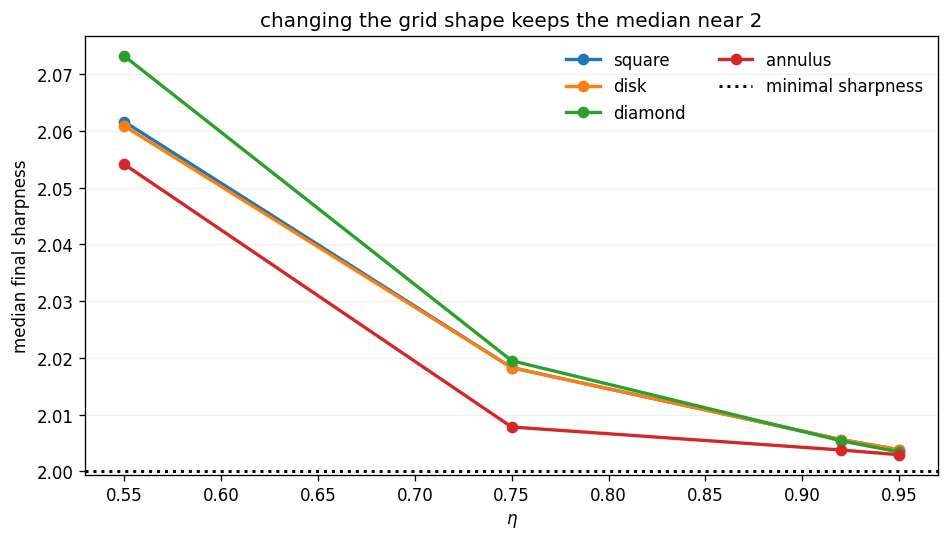

eta=0.55 |   square | grid=19881 | converged=0.597 | median s_final=2.062 | p90 s_final=2.771
eta=0.55 |     disk | grid=15373 | converged=0.769 | median s_final=2.061 | p90 s_final=2.767
eta=0.55 |  diamond | grid= 9941 | converged=0.945 | median s_final=2.073 | p90 s_final=2.805
eta=0.55 |  annulus | grid= 8532 | converged=0.592 | median s_final=2.054 | p90 s_final=2.780
eta=0.75 |   square | grid=19881 | converged=0.422 | median s_final=2.018 | p90 s_final=2.289
eta=0.75 |     disk | grid=15373 | converged=0.546 | median s_final=2.018 | p90 s_final=2.289
eta=0.75 |  diamond | grid= 9941 | converged=0.749 | median s_final=2.019 | p90 s_final=2.291
eta=0.75 |  annulus | grid= 8532 | converged=0.222 | median s_final=2.008 | p90 s_final=2.233
eta=0.92 |   square | grid=19881 | converged=0.328 | median s_final=2.006 | p90 s_final=2.081
eta=0.92 |     disk | grid=15373 | converged=0.424 | median s_final=2.006 | p90 s_final=2.081
eta=0.92 |  diamond | grid= 9941 | converged=0.610 | median 

In [4]:

def domain_summary(etas, shapes=('square', 'disk', 'diamond', 'annulus'), n=141, radius=3.0, steps=420):
    rows = []
    for eta in etas:
        for shape in shapes:
            X, Y, mask = grid_starts(n=n, radius=radius, shape=shape)
            labels, final_imbalance, *_ = run_gd_batch(X[mask], Y[mask], eta, steps=steps)
            conv = np.isin(labels, CONVERGED)
            s_final = final_sharpness(final_imbalance[conv])
            rows.append({
                'eta': float(eta),
                'shape': shape,
                'grid_points': int(labels.size),
                'converged': int(np.sum(conv)),
                'converged_share': float(np.mean(conv)),
                'median_s_final': float(np.median(s_final)),
                'p90_s_final': float(np.percentile(s_final, 90)),
            })
    return rows


def plot_domain_medians(rows):
    fig, ax = plt.subplots(figsize=(7.8, 4.4), constrained_layout=True)
    shapes = list(dict.fromkeys(row['shape'] for row in rows))
    for shape in shapes:
        sub = [row for row in rows if row['shape'] == shape]
        ax.plot(
            [row['eta'] for row in sub],
            [row['median_s_final'] for row in sub],
            marker='o',
            lw=2.0,
            label=shape,
        )
    ax.axhline(2.0, lw=1.8, ls=':', color='black', label='minimal sharpness')
    ax.set_xlabel(r'$\eta$')
    ax.set_ylabel('median final sharpness')
    ax.set_title('changing the grid shape keeps the median near 2')
    ax.grid(axis='y', alpha=0.18)
    ax.legend(frameon=False, ncols=2)
    plt.show()


domain_rows = domain_summary([0.55, 0.75, 0.92, 0.95])
plot_domain_medians(domain_rows)

for row in domain_rows:
    print(
        f"eta={row['eta']:.2f} | {row['shape']:>8} | "
        f"grid={row['grid_points']:5d} | "
        f"converged={row['converged_share']:.3f} | "
        f"median s_final={row['median_s_final']:.3f} | "
        f"p90 s_final={row['p90_s_final']:.3f}"
    )


In [5]:

def export_explorer_data(etas, save_path, n=141, radius=3.0, steps=420):
    grid = np.linspace(-radius, radius, n)
    X, Y = np.meshgrid(grid, grid)
    x = X.ravel()
    y = Y.ravel()
    payload = {
        'grid_min': float(grid[0]),
        'grid_max': float(grid[-1]),
        'grid_size': int(n),
        'steps': int(steps),
        'etas': [float(eta) for eta in etas],
        'imbalance_levels': [-4.0, -2.0, -1.0, 0.0, 1.0, 2.0, 4.0],
        'labels': {},
        'sharpness_milli': {},
        'counts': {},
    }
    for eta in etas:
        labels, imbalance, *_ = run_gd_batch(x, y, eta, steps=steps)
        conv = np.isin(labels, CONVERGED)
        sharpness_milli = np.full(labels.shape, -1, dtype=int)
        sharpness_milli[conv] = np.rint(1000.0 * (final_sharpness(imbalance[conv]) - 2.0)).astype(int)
        key = f'{eta:.2f}'
        payload['labels'][key] = ''.join(str(int(label)) for label in labels)
        payload['sharpness_milli'][key] = sharpness_milli.tolist()
        payload['counts'][key] = {str(label): int(np.sum(labels == label)) for label in range(5)}
    save_path.write_text(json.dumps(payload, separators=(',', ':')))
    return payload


explorer_payload = export_explorer_data([0.35, 0.55, 0.75, 0.92, 0.95], DATA_DIR / 'post-5-sharpness-explorer.json')
print('saved', (DATA_DIR / 'post-5-sharpness-explorer.json').relative_to(ROOT))
for eta in explorer_payload['etas']:
    key = f'{eta:.2f}'
    print(key, explorer_payload['counts'][key])


saved assets/data/post-5-sharpness-explorer.json
0.35 {'0': 6446, '1': 11110, '2': 113, '3': 2208, '4': 4}
0.55 {'0': 0, '1': 11864, '2': 75, '3': 7938, '4': 4}
0.75 {'0': 0, '1': 8388, '2': 61, '3': 11428, '4': 4}
0.92 {'0': 0, '1': 6518, '2': 51, '3': 13276, '4': 36}
0.95 {'0': 0, '1': 6182, '2': 49, '3': 13550, '4': 100}
